In [1]:
import os
import glob
import time

import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec

from sklearn.metrics import precision_score, recall_score, f1_score

In [2]:
def load_frames_from_folder(folder_path, pattern="*.jpg", max_frames=300):
    paths = sorted(glob.glob(os.path.join(folder_path, pattern)))[:max_frames]
    if not paths:
        paths = sorted(glob.glob(os.path.join(folder_path, "*.png")))[:max_frames]
    frames = [cv2.imread(p) for p in paths if cv2.imread(p) is not None]
    print(f"[INFO] Loaded {len(frames)} frames")
    return frames


def load_frames_from_video(video_path, max_frames=300):
    cap = cv2.VideoCapture(video_path)
    frames = []
    while cap.isOpened() and len(frames) < max_frames:
        ret, frame = cap.read()
        if not ret:
            break
        frames.append(frame)
    cap.release()
    print(f"[INFO] Loaded {len(frames)} frames")
    return frames

In [3]:
def generate_synthetic_surveillance(n_frames=150, h=240, w=320):
    frames, gt_masks = [], []
    rng = np.random.default_rng(42)

    background = np.full((h, w, 3), 120, dtype=np.uint8)

    for t in range(n_frames):
        frame = background.copy()
        gt = np.zeros((h, w), dtype=np.uint8)

        cx = int(30 + (w - 60) * (t / n_frames))
        cy = h // 2

        cv2.rectangle(frame, (cx-10, cy-25), (cx+10, cy+25), (255, 255, 255), -1)
        gt[cy-25:cy+25, cx-10:cx+10] = 255

        frames.append(frame)
        gt_masks.append(gt)

    return frames, gt_masks

In [4]:
def apply_gaussian_smoothing(frame, kernel_size=5, sigma=1.0):
    ksize = kernel_size if kernel_size % 2 == 1 else kernel_size + 1
    return cv2.GaussianBlur(frame, (ksize, ksize), sigma)

In [5]:
def create_gmm_subtractor(history=500, var_threshold=16, detect_shadows=True):
    return cv2.createBackgroundSubtractorMOG2(
        history=history,
        varThreshold=var_threshold,
        detectShadows=detect_shadows
    )


def apply_gmm_subtraction(subtractor, frame):
    mask = subtractor.apply(frame)
    _, binary = cv2.threshold(mask, 200, 255, cv2.THRESH_BINARY)
    return binary

In [6]:
def morphological_opening(mask, kernel_size=3):
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (kernel_size, kernel_size))
    return cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)


def morphological_closing(mask, kernel_size=11):
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (kernel_size, kernel_size))
    return cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)

In [7]:
def detect_humans(mask, min_area=300):
    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(mask)

    humans = []
    for i in range(1, num_labels):
        x, y, w, h, area = stats[i]
        if area > min_area:
            humans.append((x, y, w, h))

    return humans

In [8]:
def draw_detections(frame, humans):
    vis = frame.copy()
    for (x, y, w, h) in humans:
        cv2.rectangle(vis, (x, y), (x+w, y+h), (0, 0, 255), 2)
    return vis

In [9]:
def evaluate_mask(pred, gt):
    pred = (pred > 0).astype(int).flatten()
    gt   = (gt > 0).astype(int).flatten()

    tp = np.sum((pred == 1) & (gt == 1))
    fp = np.sum((pred == 1) & (gt == 0))
    fn = np.sum((pred == 0) & (gt == 1))

    precision = tp / (tp + fp + 1e-8)
    recall    = tp / (tp + fn + 1e-8)
    f1        = 2 * precision * recall / (precision + recall + 1e-8)
    iou       = tp / (tp + fp + fn + 1e-8)

    return precision, recall, f1, iou

In [10]:
def show_pipeline(frame, smoothed, mask, refined, result):
    plt.figure(figsize=(12,6))

    plt.subplot(1,5,1)
    plt.imshow(frame[...,::-1]); plt.title("Original"); plt.axis('off')

    plt.subplot(1,5,2)
    plt.imshow(smoothed[...,::-1]); plt.title("Smoothed"); plt.axis('off')

    plt.subplot(1,5,3)
    plt.imshow(mask, cmap='gray'); plt.title("Mask"); plt.axis('off')

    plt.subplot(1,5,4)
    plt.imshow(refined, cmap='gray'); plt.title("Refined"); plt.axis('off')

    plt.subplot(1,5,5)
    plt.imshow(result[...,::-1]); plt.title("Detection"); plt.axis('off')

    plt.show()

In [11]:
def run_pipeline():
    frames, gt_masks = generate_synthetic_surveillance()

    subtractor = create_gmm_subtractor()

    for i, frame in enumerate(frames):
        smoothed = apply_gaussian_smoothing(frame)

        mask = apply_gmm_subtraction(subtractor, smoothed)

        opened = morphological_opening(mask)
        closed = morphological_closing(opened)

        humans = detect_humans(closed)

        result = draw_detections(frame, humans)

        if i % 30 == 0:
            show_pipeline(frame, smoothed, mask, closed, result)

        if i < len(gt_masks):
            p, r, f1, iou = evaluate_mask(closed, gt_masks[i])
            print(f"Frame {i}: F1={f1:.3f}, IoU={iou:.3f}")

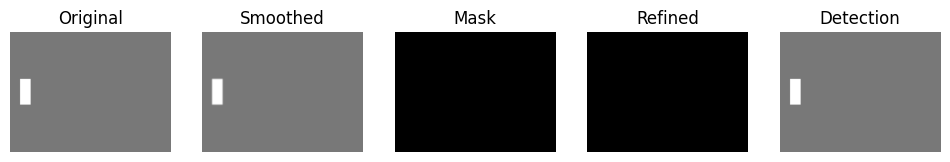

Frame 0: F1=0.000, IoU=0.000
Frame 1: F1=0.000, IoU=0.000
Frame 2: F1=0.000, IoU=0.000
Frame 3: F1=0.000, IoU=0.000
Frame 4: F1=0.000, IoU=0.000
Frame 5: F1=0.159, IoU=0.086
Frame 6: F1=0.159, IoU=0.086
Frame 7: F1=0.159, IoU=0.086
Frame 8: F1=0.083, IoU=0.043
Frame 9: F1=0.159, IoU=0.086
Frame 10: F1=0.158, IoU=0.086
Frame 11: F1=0.228, IoU=0.129
Frame 12: F1=0.000, IoU=0.000
Frame 13: F1=0.000, IoU=0.000
Frame 14: F1=0.158, IoU=0.086
Frame 15: F1=0.226, IoU=0.128
Frame 16: F1=0.157, IoU=0.085
Frame 17: F1=0.157, IoU=0.085
Frame 18: F1=0.157, IoU=0.085
Frame 19: F1=0.157, IoU=0.085
Frame 20: F1=0.290, IoU=0.169
Frame 21: F1=0.290, IoU=0.169
Frame 22: F1=0.290, IoU=0.169
Frame 23: F1=0.290, IoU=0.169
Frame 24: F1=0.404, IoU=0.253
Frame 25: F1=0.402, IoU=0.252
Frame 26: F1=0.402, IoU=0.252
Frame 27: F1=0.348, IoU=0.211
Frame 28: F1=0.402, IoU=0.252
Frame 29: F1=0.500, IoU=0.333


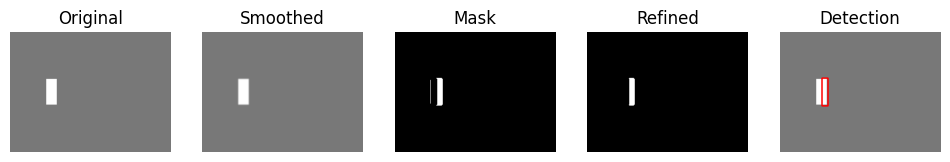

Frame 30: F1=0.500, IoU=0.333
Frame 31: F1=0.453, IoU=0.293
Frame 32: F1=0.453, IoU=0.293
Frame 33: F1=0.500, IoU=0.333
Frame 34: F1=0.543, IoU=0.373
Frame 35: F1=0.543, IoU=0.373
Frame 36: F1=0.543, IoU=0.373
Frame 37: F1=0.543, IoU=0.373
Frame 38: F1=0.586, IoU=0.414
Frame 39: F1=0.623, IoU=0.452
Frame 40: F1=0.623, IoU=0.452
Frame 41: F1=0.623, IoU=0.452
Frame 42: F1=0.623, IoU=0.452
Frame 43: F1=0.696, IoU=0.533
Frame 44: F1=0.693, IoU=0.530
Frame 45: F1=0.693, IoU=0.530
Frame 46: F1=0.694, IoU=0.532
Frame 47: F1=0.727, IoU=0.570
Frame 48: F1=0.758, IoU=0.610
Frame 49: F1=0.725, IoU=0.569
Frame 50: F1=0.725, IoU=0.569
Frame 51: F1=0.757, IoU=0.609
Frame 52: F1=0.785, IoU=0.647
Frame 53: F1=0.787, IoU=0.649
Frame 54: F1=0.784, IoU=0.645
Frame 55: F1=0.813, IoU=0.684
Frame 56: F1=0.838, IoU=0.722
Frame 57: F1=0.813, IoU=0.684
Frame 58: F1=0.837, IoU=0.719
Frame 59: F1=0.863, IoU=0.759


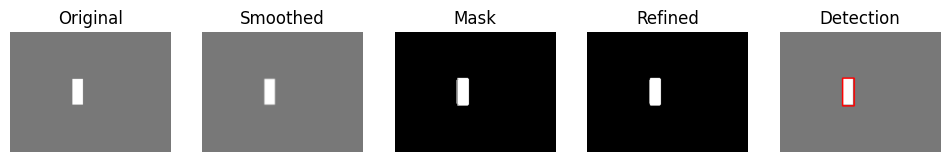

Frame 60: F1=0.887, IoU=0.796
Frame 61: F1=0.863, IoU=0.759
Frame 62: F1=0.888, IoU=0.798
Frame 63: F1=0.885, IoU=0.793
Frame 64: F1=0.886, IoU=0.796
Frame 65: F1=0.848, IoU=0.736
Frame 66: F1=0.847, IoU=0.735
Frame 67: F1=0.846, IoU=0.734
Frame 68: F1=0.846, IoU=0.734
Frame 69: F1=0.846, IoU=0.734
Frame 70: F1=0.846, IoU=0.734
Frame 71: F1=0.846, IoU=0.734
Frame 72: F1=0.846, IoU=0.734
Frame 73: F1=0.846, IoU=0.734
Frame 74: F1=0.846, IoU=0.734
Frame 75: F1=0.846, IoU=0.734
Frame 76: F1=0.846, IoU=0.734
Frame 77: F1=0.846, IoU=0.734
Frame 78: F1=0.846, IoU=0.734
Frame 79: F1=0.846, IoU=0.734
Frame 80: F1=0.846, IoU=0.734
Frame 81: F1=0.846, IoU=0.734
Frame 82: F1=0.846, IoU=0.734
Frame 83: F1=0.846, IoU=0.734
Frame 84: F1=0.846, IoU=0.734
Frame 85: F1=0.846, IoU=0.734
Frame 86: F1=0.846, IoU=0.734
Frame 87: F1=0.846, IoU=0.734
Frame 88: F1=0.846, IoU=0.734
Frame 89: F1=0.846, IoU=0.734


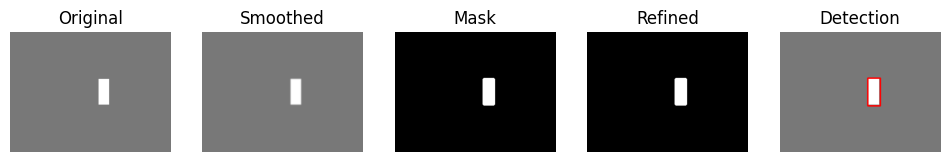

Frame 90: F1=0.846, IoU=0.734
Frame 91: F1=0.846, IoU=0.734
Frame 92: F1=0.846, IoU=0.734
Frame 93: F1=0.846, IoU=0.734
Frame 94: F1=0.846, IoU=0.734
Frame 95: F1=0.846, IoU=0.734
Frame 96: F1=0.846, IoU=0.734
Frame 97: F1=0.846, IoU=0.734
Frame 98: F1=0.846, IoU=0.734
Frame 99: F1=0.846, IoU=0.734
Frame 100: F1=0.846, IoU=0.734
Frame 101: F1=0.846, IoU=0.734
Frame 102: F1=0.846, IoU=0.734
Frame 103: F1=0.846, IoU=0.734
Frame 104: F1=0.846, IoU=0.734
Frame 105: F1=0.846, IoU=0.734
Frame 106: F1=0.846, IoU=0.734
Frame 107: F1=0.846, IoU=0.734
Frame 108: F1=0.846, IoU=0.734
Frame 109: F1=0.846, IoU=0.734
Frame 110: F1=0.846, IoU=0.734
Frame 111: F1=0.846, IoU=0.734
Frame 112: F1=0.846, IoU=0.734
Frame 113: F1=0.846, IoU=0.734
Frame 114: F1=0.846, IoU=0.734
Frame 115: F1=0.846, IoU=0.734
Frame 116: F1=0.846, IoU=0.734
Frame 117: F1=0.846, IoU=0.734
Frame 118: F1=0.846, IoU=0.734
Frame 119: F1=0.846, IoU=0.734


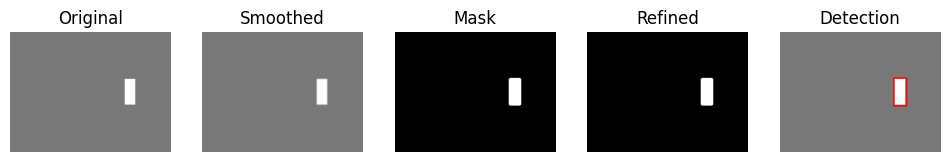

Frame 120: F1=0.846, IoU=0.734
Frame 121: F1=0.846, IoU=0.734
Frame 122: F1=0.846, IoU=0.734
Frame 123: F1=0.846, IoU=0.734
Frame 124: F1=0.846, IoU=0.734
Frame 125: F1=0.846, IoU=0.734
Frame 126: F1=0.846, IoU=0.734
Frame 127: F1=0.846, IoU=0.734
Frame 128: F1=0.846, IoU=0.734
Frame 129: F1=0.846, IoU=0.734
Frame 130: F1=0.846, IoU=0.734
Frame 131: F1=0.846, IoU=0.734
Frame 132: F1=0.846, IoU=0.734
Frame 133: F1=0.846, IoU=0.734
Frame 134: F1=0.846, IoU=0.734
Frame 135: F1=0.846, IoU=0.734
Frame 136: F1=0.846, IoU=0.734
Frame 137: F1=0.846, IoU=0.734
Frame 138: F1=0.846, IoU=0.734
Frame 139: F1=0.846, IoU=0.734
Frame 140: F1=0.846, IoU=0.734
Frame 141: F1=0.846, IoU=0.734
Frame 142: F1=0.846, IoU=0.734
Frame 143: F1=0.846, IoU=0.734
Frame 144: F1=0.846, IoU=0.734
Frame 145: F1=0.846, IoU=0.734
Frame 146: F1=0.846, IoU=0.734
Frame 147: F1=0.846, IoU=0.734
Frame 148: F1=0.846, IoU=0.734
Frame 149: F1=0.846, IoU=0.734


In [12]:
run_pipeline()